# QR Navigation — Results Analysis

Single notebook that consumes every CSV produced by `data_logger_node` and emits Section V's tables and figures (Phase 3 Step 0). Run top-to-bottom; each section is self-contained.

**Inputs:** `repo/results/t{1..6}_*.csv` (one per trial set, see `phases/phase-2-experiments.md` and `phase-2-runbook.md`).

**Outputs:**
- `repo/results/t1_summary.csv` — Table V.2.1 source
- `repo/results/figures/*.png` — every figure referenced in V.2

**Run order:**
1. **Setup** — imports, paths.
2. **T1 — Per-command accuracy** — fully implemented.
3. **T2–T6** — placeholder cells; fill in as each CSV lands.

## 1. Setup

In [89]:
%matplotlib inline

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo-relative paths regardless of where the kernel was started.
HERE = Path.cwd()
REPO_ROOT = next(p for p in [HERE, *HERE.parents] if (p / 'repo').exists() or p.name == 'PAR-A3')
RESULTS = REPO_ROOT / 'repo' / 'results' if (REPO_ROOT / 'repo' / 'results').exists() else REPO_ROOT / 'results'
FIGS = RESULTS / 'figures'
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Canonical command order (used for every per-command plot/table).
CMD_ORDER = ['GO', 'STOP', 'TURN_LEFT', 'TURN_RIGHT', 'U_TURN', 'SPEED_UP', 'SPEED_DOWN']

# Expected /cmd_vel response per command (linear m/s, angular rad/s). None means
# 'don't check this axis' — used for SPEED_UP/DOWN where the linear value is
# state-dependent (depends on the current cruise_speed).
EXPECTED_VEL = {
    'GO':         (None, 0.0),   # any non-zero forward + zero angular
    'STOP':       (0.0,  0.0),
    'TURN_LEFT':  (0.0,  0.4),
    'TURN_RIGHT': (0.0, -0.4),
    'U_TURN':     (0.0,  0.4),   # or -0.4; sign is configuration-dependent
    'SPEED_UP':   (None, 0.0),
    'SPEED_DOWN': (None, 0.0),
}

print(f'RESULTS = {RESULTS}')
print(f'FIGS    = {FIGS}')
print(f'CSVs available:')
for p in sorted(RESULTS.glob('*.csv')):
    print(f'  {p.name}')

RESULTS = /Users/lintran/Documents/Coding/PAR-A3/repo/results
FIGS    = /Users/lintran/Documents/Coding/PAR-A3/repo/results/figures
CSVs available:
  t1_per_command_20260521_201104.csv
  t1_pilot.csv
  t1_summary.csv
  t2_distance_20260522_061551.csv
  t2_distance_20260522_065600.csv
  t2_distance_20260522_073001.csv
  t2_summary.csv
  t3_angle_20260522_075134.csv
  t3_summary.csv
  t4_lighting_20260522_083408.csv
  t4_summary.csv
  t5_pairs.csv
  t5_simultaneous_20260522_093952.csv
  t5_summary.csv


## 2. T1 — Per-command accuracy

Drives Section V.2.1 (overall accuracy table + per-command numbers).

### 2.1 — Load T1 CSV

In [90]:
t1_candidates = sorted(RESULTS.glob('t1_per_command_*.csv'))
assert t1_candidates, f'No T1 CSV found under {RESULTS}'
T1_PATH = t1_candidates[-1]   # most recent run
print(f'Using {T1_PATH.name}')

df = pd.read_csv(T1_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])

duration_s = df['elapsed_s'].max()
log_rate = len(df) / duration_s
print(f'Rows:     {len(df):,}')
print(f'Duration: {duration_s:.1f} s  ({duration_s/60:.1f} min)')
print(f'Log rate: {log_rate:.1f} Hz')

Using t1_per_command_20260521_201104.csv
Rows:     3,838
Duration: 767.6 s  (12.8 min)
Log rate: 5.0 Hz


### 2.2 — Extract detection events

In [91]:
def get_bbox(s):
    """Pull bbox_area out of the all_detections JSON."""
    try:
        return json.loads(s)[0]['bbox_area']
    except Exception:
        return np.nan

events = df[df['detection_event'] == True].copy()
events['bbox_area'] = events['all_detections'].apply(get_bbox)

print(f'Total detection events: {len(events)}')
print(f'\nPer-command counts:')
print(events['qr_command'].value_counts().reindex(CMD_ORDER, fill_value=0).to_string())

Total detection events: 75

Per-command counts:
qr_command
GO            17
STOP          18
TURN_LEFT      8
TURN_RIGHT     8
U_TURN         8
SPEED_UP       8
SPEED_DOWN     8


### 2.3 — Execution accuracy with one-tick lookahead

The 5 Hz log rate sometimes catches the FSM state mid-transition: `nav_state = TURNING` but `cmd_angular_z = 0` because the interpreter's next `/cmd_vel` publish hasn't landed yet (20 Hz vs 5 Hz). To filter this artefact, we check the **last** `cmd_vel` value within a 1.0 s window after the detection event, not the row itself.

In [92]:
def execution_correct(row, df, window_s=1.0, lin_tol=0.01, ang_tol=0.05):
    """Return True if /cmd_vel matches the expected response within the window."""
    expected = EXPECTED_VEL.get(row['qr_command'])
    if expected is None:
        return None
    exp_lin, exp_ang = expected
    window = df[(df['elapsed_s'] >= row['elapsed_s'])
                & (df['elapsed_s'] <= row['elapsed_s'] + window_s)]
    if window.empty:
        return False
    last = window.iloc[-1]
    # 'None' on the linear axis means 'just check non-zero / direction'.
    if exp_lin is None:
        lin_ok = last['cmd_linear_x'] > 0 if row['qr_command'] in ('GO', 'SPEED_UP', 'SPEED_DOWN') else True
    else:
        lin_ok = abs(last['cmd_linear_x'] - exp_lin) < lin_tol
    # U_TURN can rotate either direction; just require magnitude.
    if row['qr_command'] == 'U_TURN':
        ang_ok = abs(abs(last['cmd_angular_z']) - abs(exp_ang)) < ang_tol
    else:
        ang_ok = abs(last['cmd_angular_z'] - exp_ang) < ang_tol
    return bool(lin_ok and ang_ok)

events['exec_ok'] = events.apply(lambda r: execution_correct(r, df), axis=1)

print(f'Execution-correct events: {events["exec_ok"].sum()} / {events["exec_ok"].notna().sum()}')

Execution-correct events: 75 / 75


### 2.4 — Table V.2.1 — per-command summary

In [93]:
summary = events.groupby('qr_command').agg(
    n=('qr_command', 'count'),
    exec_ok=('exec_ok', 'sum'),
    mean_bbox=('bbox_area', 'mean'),
    median_bbox=('bbox_area', 'median'),
    min_bbox=('bbox_area', 'min'),
    max_bbox=('bbox_area', 'max'),
).reindex(CMD_ORDER)

summary['exec_rate_%'] = (summary['exec_ok'] / summary['n'] * 100).round(1)
summary['detection_rate_%'] = 100.0   # all rows in `events` were detected; see caveat in chat

summary = summary[['n', 'detection_rate_%', 'exec_rate_%',
                   'mean_bbox', 'median_bbox', 'min_bbox', 'max_bbox']]
summary[['mean_bbox', 'median_bbox', 'min_bbox', 'max_bbox']] = (
    summary[['mean_bbox', 'median_bbox', 'min_bbox', 'max_bbox']].round(0)
)

# Overall row
summary.loc['Overall'] = [
    summary['n'].sum(),
    100.0,
    round(events['exec_ok'].sum() / events['exec_ok'].notna().sum() * 100, 1),
    round(events['bbox_area'].mean(), 0),
    round(events['bbox_area'].median(), 0),
    round(events['bbox_area'].min(), 0),
    round(events['bbox_area'].max(), 0),
]

summary

,n,detection_rate_%,exec_rate_%,mean_bbox,median_bbox,min_bbox,max_bbox
qr_command,,,,,,,
GO,17.0,100.0,100.0,9482.0,9001.0,5665.0,14161.0
STOP,18.0,100.0,100.0,10864.0,10122.0,5550.0,18558.0
TURN_LEFT,8.0,100.0,100.0,15529.0,15042.0,11096.0,21559.0
TURN_RIGHT,8.0,100.0,100.0,21324.0,16247.0,8548.0,63228.0
U_TURN,8.0,100.0,100.0,12703.0,13372.0,4702.0,16940.0
SPEED_UP,8.0,100.0,100.0,8750.0,7482.0,5718.0,15745.0
SPEED_DOWN,8.0,100.0,100.0,13044.0,11857.0,6590.0,18294.0
Overall,75.0,100.0,100.0,12388.0,11094.0,4702.0,63228.0


### 2.5 — Figure: detection counts per command

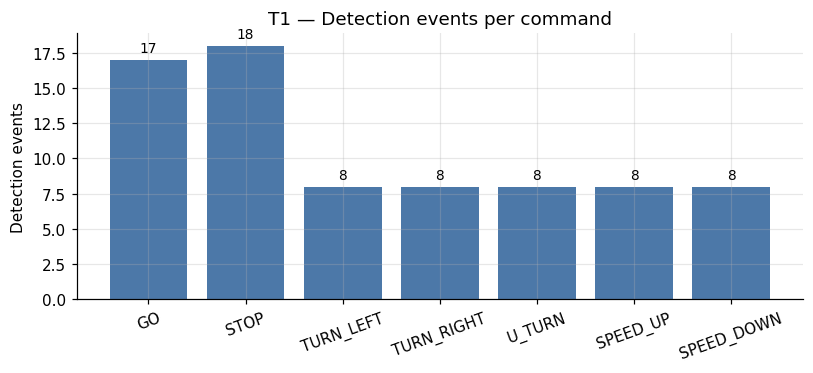

In [94]:
counts = events['qr_command'].value_counts().reindex(CMD_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(7.5, 3.5))
bars = ax.bar(counts.index, counts.values, color='#4c78a8')
ax.set_ylabel('Detection events')
ax.set_title('T1 — Detection events per command')
ax.tick_params(axis='x', rotation=20)
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n + max(counts.values) * 0.02,
            str(n), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
fig.savefig(FIGS / 't1_detection_counts.png', bbox_inches='tight')
plt.show()

### 2.6 — Figure: bounding-box area distribution

The horizontal lines show the two threshold values that appear in T6 (`min_bbox_area = 500 px²` default, `1500 px²` T6 baseline). All T1 detections sit comfortably above both — supports the choice of those thresholds in V.2.4.

/var/folders/lm/pf574n5n4tb8f4w0gnt8pd880000gp/T/ipykernel_92819/844177600.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=CMD_ORDER, patch_artist=True,


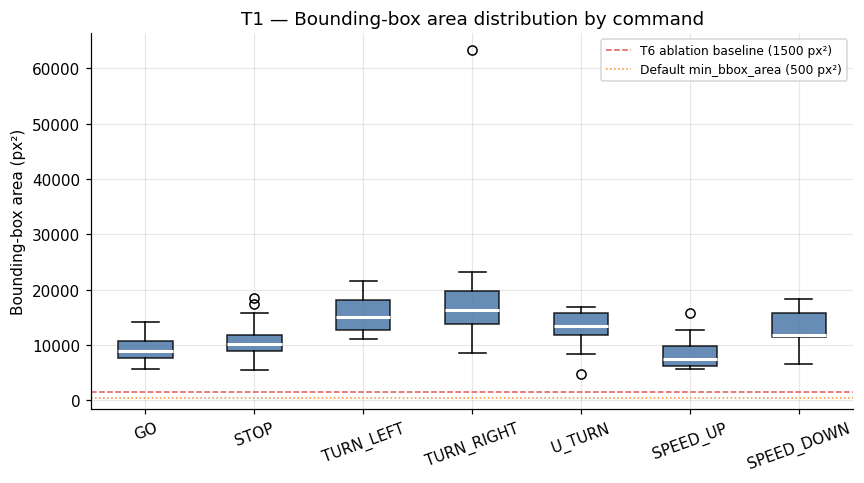

In [95]:
data = [events[events['qr_command'] == c]['bbox_area'].dropna().values for c in CMD_ORDER]

fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(data, labels=CMD_ORDER, patch_artist=True,
                medianprops={'color': 'white', 'linewidth': 2})
for patch in bp['boxes']:
    patch.set_facecolor('#4c78a8')
    patch.set_alpha(0.85)
ax.axhline(1500, color='#e15759', linestyle='--', linewidth=1,
           label='T6 ablation baseline (1500 px²)')
ax.axhline(500, color='#f28e2b', linestyle=':', linewidth=1,
           label='Default min_bbox_area (500 px²)')
ax.set_ylabel('Bounding-box area (px²)')
ax.set_title('T1 — Bounding-box area distribution by command')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
fig.savefig(FIGS / 't1_bbox_distribution.png', bbox_inches='tight')
plt.show()

### 2.7 — Figure: detection timeline

Each marker is one detection event; marker size scales with bbox area. The horizontal banding makes the round structure visible — you can count the rounds visually.

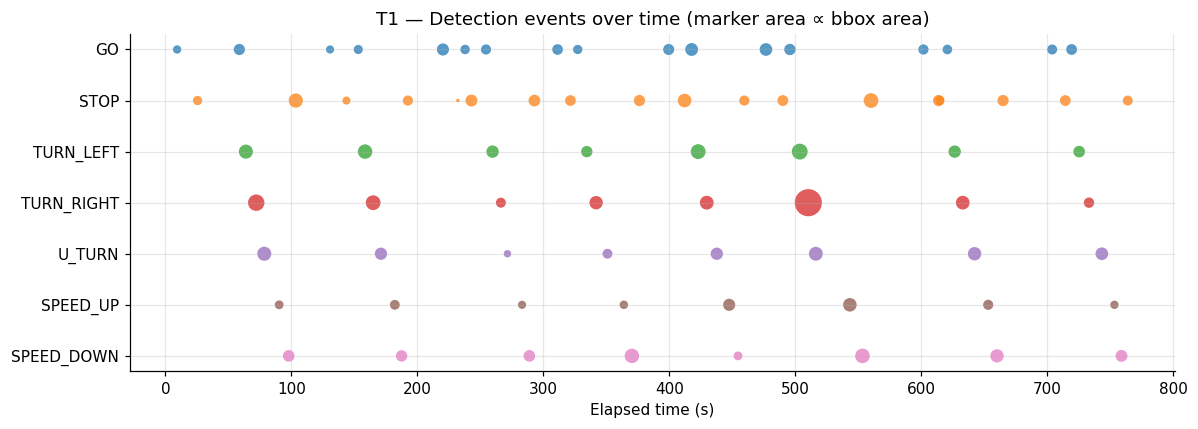

In [96]:
cmap = plt.get_cmap('tab10')
cmd_to_color = {c: cmap(i) for i, c in enumerate(CMD_ORDER)}

fig, ax = plt.subplots(figsize=(11, 4))
for cmd in CMD_ORDER:
    sub = events[events['qr_command'] == cmd]
    if sub.empty:
        continue
    ax.scatter(sub['elapsed_s'], [cmd] * len(sub),
               s=sub['bbox_area'].fillna(1000) / 200,
               c=[cmd_to_color[cmd]], alpha=0.75, edgecolors='none')
ax.set_xlabel('Elapsed time (s)')
ax.set_title('T1 — Detection events over time (marker area ∝ bbox area)')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIGS / 't1_timeline.png', bbox_inches='tight')
plt.show()

### 2.8 — Figure: FSM state dwell

Time spent in each finite-state-machine state across the entire session. `RECOVERING` dominating is expected for a human-paced trial (operator gap > `recovery_timeout = 3.0 s`).

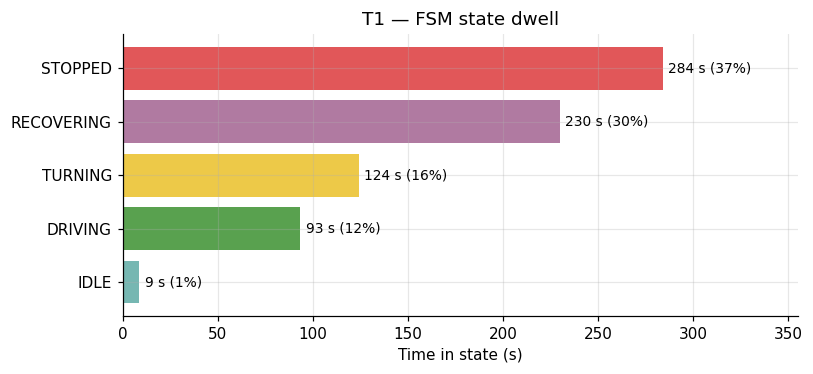

In [97]:
# Self-contained: re-load if any of df / RESULTS / FIGS / duration_s isn't
# already in scope (i.e. this cell was run standalone after a kernel restart).
if 'df' not in globals() or 'RESULTS' not in globals() or 'FIGS' not in globals():
    from pathlib import Path
    import pandas as pd
    import matplotlib.pyplot as plt
    _here = Path.cwd()
    _repo_root = next(
        (p for p in [_here, *_here.parents]
         if (p / 'repo' / 'results').exists() or p.name.lower() == 'par-a3'),
        _here,
    )
    RESULTS = next(
        c for c in (_repo_root / 'repo' / 'results', _repo_root / 'results')
        if c.exists()
    )
    FIGS = RESULTS / 'figures'
    FIGS.mkdir(exist_ok=True)
    df = pd.read_csv(sorted(RESULTS.glob('t1_per_command_*.csv'))[-1])
if 'duration_s' not in globals():
    duration_s = df['elapsed_s'].max()

# Compute contiguous runs of each state.
# Pre-arming rows have NaN nav_state because the FSM hasn't yet published its
# first state — semantically that's IDLE, so we fill it in. (Some builds of
# data_logger_node emit 'IDLE' explicitly here; this handles both cases.)
df_states = df.copy()
df_states['nav_state'] = df_states['nav_state'].fillna('IDLE')
df_states['run_id'] = (df_states['nav_state'] != df_states['nav_state'].shift()).cumsum()
runs = df_states.groupby('run_id').agg(
    state=('nav_state', 'first'),
    start=('elapsed_s', 'first'),
    end=('elapsed_s', 'last'),
)
runs['dwell'] = runs['end'] - runs['start']
dwell = runs.groupby('state')['dwell'].sum().sort_values()

fig, ax = plt.subplots(figsize=(7.5, 3.5))
state_colors = {
    'IDLE': '#76b7b2', 'DRIVING': '#59a14f', 'TURNING': '#edc948',
    'STOPPED': '#e15759', 'RECOVERING': '#b07aa1',
}
bars = ax.barh(dwell.index, dwell.values,
               color=[state_colors.get(s, '#888') for s in dwell.index])
ax.set_xlabel('Time in state (s)')
ax.set_title('T1 — FSM state dwell')
ax.set_xlim(0, dwell.max() * 1.25)
for bar, d in zip(bars, dwell.values):
    ax.text(d + dwell.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{d:.0f} s ({d / duration_s * 100:.0f}%)',
            va='center', fontsize=9)
plt.tight_layout()
fig.savefig(FIGS / 't1_state_dwell.png', bbox_inches='tight')
plt.show()

### 2.9 — Figure: velocity commands over time

Two-panel plot of `cmd_linear_x` and `cmd_angular_z`. Each grey vertical line is a detection event. Use this to spot-check execution-correctness visually — TURN events should produce angular spikes, STOP events should drive both panels to zero, etc.

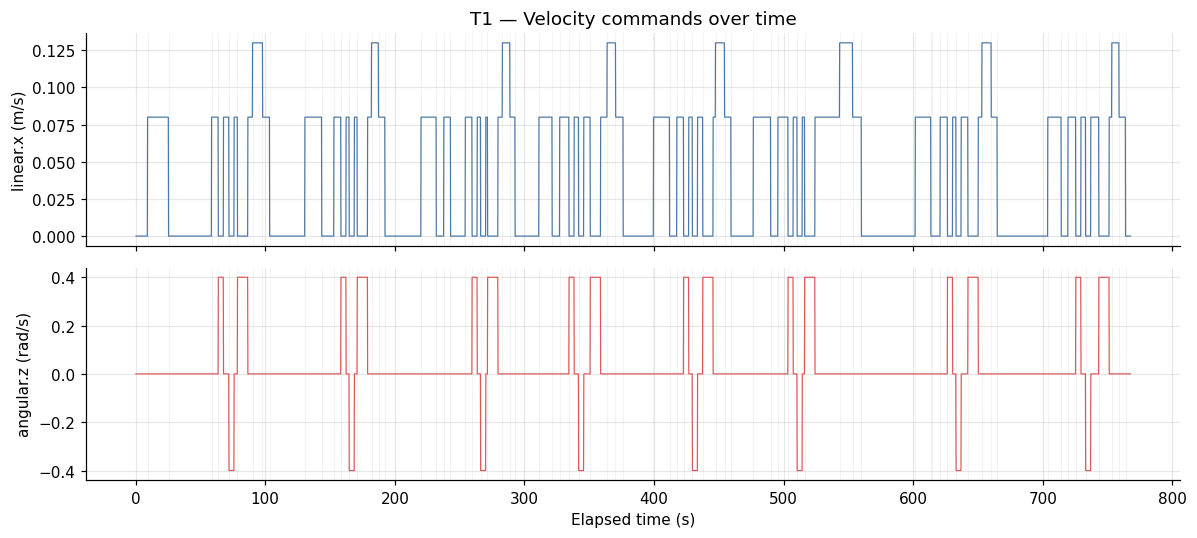

In [98]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

ax1.plot(df['elapsed_s'], df['cmd_linear_x'], color='#4c78a8', linewidth=0.8)
ax1.set_ylabel('linear.x (m/s)')
ax1.set_title('T1 — Velocity commands over time')

ax2.plot(df['elapsed_s'], df['cmd_angular_z'], color='#e15759', linewidth=0.8)
ax2.set_ylabel('angular.z (rad/s)')
ax2.set_xlabel('Elapsed time (s)')

for _, ev in events.iterrows():
    ax1.axvline(ev['elapsed_s'], color='grey', alpha=0.12, linewidth=0.5)
    ax2.axvline(ev['elapsed_s'], color='grey', alpha=0.12, linewidth=0.5)

plt.tight_layout()
fig.savefig(FIGS / 't1_cmd_vel.png', bbox_inches='tight')
plt.show()

### 2.10 — Export summary

In [99]:
out = RESULTS / 't1_summary.csv'
summary.to_csv(out)
print(f'Wrote: {out}')
print(f'\nFigures in {FIGS}:')
for p in sorted(FIGS.glob('t1_*.png')):
    print(f'  {p.name}  ({p.stat().st_size // 1024} KB)')

Wrote: /Users/lintran/Documents/Coding/PAR-A3/repo/results/t1_summary.csv

Figures in /Users/lintran/Documents/Coding/PAR-A3/repo/results/figures:
  t1_bbox_distribution.png  (90 KB)
  t1_cmd_vel.png  (146 KB)
  t1_detection_counts.png  (59 KB)
  t1_state_dwell.png  (45 KB)
  t1_timeline.png  (80 KB)


## 3. T2 — Distance sweep

Drives **Figure F5a** (accuracy vs distance) and **V.2.2** distance subsection.

**Protocol** (per `phase-2-experiments.md`): STOP card only, four distances — 0.3 m → 0.6 m → 1.0 m → 1.5 m — ten reps per distance, 40 total. Robot stationary in IDLE throughout.

**What the CSV captures vs what it doesn't**
- ✅ Each detection event with its `bbox_area` (px²)
- ❌ The card's *distance* (operator measures with tape, doesn't enter the logger)
- ❌ Reps that the detector *missed entirely* (no event row = no record at all)

**How this section infers distance**
1. Auto-segments the events into blocks by inter-event gap (the operator paused to walk between distance marks).
2. Default-maps blocks to the protocol order (0.3 → 0.6 → 1.0 → 1.5 m). **Edit `BLOCK_DISTANCES` below** if your operator notes contradict the order.
3. Sanity-checks the mapping against `bbox_area` (should scale roughly ∝ 1/d²).

**⚠ Operator-data caveat.** Detection rate = `reps_detected / REPS_PER_BLOCK`. If you stopped a block early or skipped reps, **edit `REPS_PER_BLOCK`** — otherwise the rate is an under-estimate. The notebook can't tell a "true detector miss" from a "rep that was never attempted"; only `notes/trial2.md` can.

### 3.1 — Load T2 CSV

Picks the most recent `t2_distance_*.csv` from `repo/results/`.

In [100]:
# Self-contained: re-load core paths if running this cell standalone.
if 'RESULTS' not in globals() or 'FIGS' not in globals():
    from pathlib import Path
    import json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    _here = Path.cwd()
    _repo_root = next(
        (p for p in [_here, *_here.parents]
         if (p / 'repo' / 'results').exists() or p.name.lower() == 'par-a3'),
        _here,
    )
    RESULTS = next(
        c for c in (_repo_root / 'repo' / 'results', _repo_root / 'results')
        if c.exists()
    )
    FIGS = RESULTS / 'figures'
    FIGS.mkdir(exist_ok=True)

t2_paths = sorted(RESULTS.glob('t2_distance_20260522_073001.csv'))
assert t2_paths, f"No t2_distance_*.csv found in {RESULTS}"
T2_PATH = t2_paths[-1]
df_t2 = pd.read_csv(T2_PATH)
duration_t2 = df_t2['elapsed_s'].max()
print(f"Loaded {T2_PATH.name}")
print(f"  rows: {len(df_t2)}    duration: {duration_t2:.1f} s")
print(f"  detection_event=True rows: {int(df_t2['detection_event'].sum())}")

Loaded t2_distance_20260522_073001.csv
  rows: 962    duration: 192.5 s
  detection_event=True rows: 32


### 3.2 — Extract detection events + `bbox_area`

Each event has a JSON payload in `all_detections`; we pull `bbox_area` out the same way as T1.

In [101]:
def _bbox_of(s):
    """Pull bbox_area out of the first detection in the all_detections JSON."""
    try:
        items = json.loads(s)
        return items[0]['bbox_area'] if items else None
    except (TypeError, json.JSONDecodeError):
        return None

events_t2 = df_t2[df_t2['detection_event'] == True].copy()
events_t2['bbox_area'] = events_t2['all_detections'].apply(_bbox_of)
events_t2 = events_t2[['elapsed_s', 'qr_command', 'bbox_area']].reset_index(drop=True)

print(f"detection events: {len(events_t2)}")
print(f"commands: {events_t2['qr_command'].value_counts().to_dict()}")
events_t2.round({'elapsed_s': 2, 'bbox_area': 0})

detection events: 32
commands: {'STOP': 32}


,elapsed_s,qr_command,bbox_area
0,28.26,STOP,23331.0
1,33.86,STOP,25734.0
2,37.06,STOP,24671.0
3,41.06,STOP,25913.0
4,44.46,STOP,27476.0
5,48.06,STOP,28797.0
6,51.86,STOP,29312.0
7,55.86,STOP,29442.0
8,58.26,STOP,28527.0
9,61.46,STOP,32957.0


### 3.3 — Auto-detect block boundaries

T2 alternates between *"show 10 reps at distance X"* and *"walk to next mark"*. The walk takes much longer than the per-rep withdraw cooldown (~1 s). Any inter-event gap larger than `BLOCK_GAP_S` (default **5 s**) starts a new block. Tune if your operator paced differently.

In [102]:
BLOCK_GAP_S = 5.0  # gap (s) that splits one block from the next

events_t2 = events_t2.sort_values('elapsed_s').reset_index(drop=True)
events_t2['gap_s'] = events_t2['elapsed_s'].diff()
events_t2['block'] = (events_t2['gap_s'].fillna(0) > BLOCK_GAP_S).cumsum()

block_stats = events_t2.groupby('block').agg(
    n_events=('elapsed_s', 'count'),
    t_start=('elapsed_s', 'min'),
    t_end=('elapsed_s', 'max'),
    bbox_mean=('bbox_area', 'mean'),
    bbox_std=('bbox_area', 'std'),
    bbox_min=('bbox_area', 'min'),
    bbox_max=('bbox_area', 'max'),
)
block_stats['duration_s'] = block_stats['t_end'] - block_stats['t_start']

print(f"Detected {len(block_stats)} block(s) with BLOCK_GAP_S = {BLOCK_GAP_S}s")
block_stats.round(1)

Detected 4 block(s) with BLOCK_GAP_S = 5.0s


,n_events,t_start,t_end,bbox_mean,bbox_std,bbox_min,bbox_max,duration_s
block,,,,,,,,
0,1,28.3,28.3,23331.5,NaN,23331.5,23331.5,0.0
1,9,33.9,61.5,28092.1,2501.4,24671.0,32956.8,27.6
2,10,71.7,102.7,13350.3,699.4,12321.6,14298.8,31.0
3,12,116.1,136.1,4455.6,108.4,4266.2,4607.9,20.0


### 3.4 — Map blocks → distances + build summary

**Edit `BLOCK_DISTANCES`** to match `notes/trial2.md`. Default assumes the operator followed the planned order (0.3 → 0.6 → 1.0 → 1.5 m). The `bbox_mean` column above is the sanity check: since `bbox_area ∝ 1/d²`, the largest bbox should be the closest distance.

If the session got split into **more than four inferred blocks** (extra pauses, repeated passes, re-tries at one distance), add more entries to `BLOCK_DISTANCES`. Multiple blocks may map to the **same** distance; the notebook will aggregate them.

**Edit `REPS_PER_BLOCK`** if any block was stopped short of 10 attempts. *This is the single biggest source of error* in the detection rate column — the notebook cannot tell a "true detector miss" from a "rep that was never attempted".

Unmapped blocks are listed as a warning and excluded from the distance-based summary/figures until you map them. The detector already enforces a 1.0 s per-command cooldown, so `n_events` ≈ unique reps detected, as long as the operator withdrew each card cleanly within 1 s (per runbook §3.6).

In [103]:
# --- EDIT THESE THREE DICTS TO MATCH notes/trial2.md ---
# Mapping for t2_distance_20260522_073001.csv:
#   - The segmenter splits blocks at any inter-event gap > BLOCK_GAP_S (5 s).
#     The first detection at t≈28 s sits 5.6 s before the next one, so block 0
#     is a single-rep "warmup" still at 0.3 m and block 1 is the rest of the
#     planned 0.3 m reps. Block 2 = 0.6 m, block 3 = 1.0 m.
#   - The 1.5 m block produced ZERO detections, so it never appears in
#     events_t2 / block_stats. It has to be declared explicitly via
#     ZERO_DETECTION_DISTANCES below — otherwise it silently drops out of
#     the per-distance summary and the F5a chart looks too optimistic.
BLOCK_DISTANCES = {  # block index → distance (m)
    0: 0.3,   # stray warmup detection (rolled into 0.3 m total)
    1: 0.3,   # planned 0.3 m block
    2: 0.6,
    3: 1.0,
    # If the session got split into extra inferred blocks, keep adding entries.
}
REPS_PER_BLOCK = {  # how many attempts you actually made in each inferred block
    0: 0,     # warmup wasn't part of the planned count — its detection rolls into 0.3 m
    1: 10,
    2: 10,
    3: 10,
}
ZERO_DETECTION_DISTANCES = {  # distance (m) → reps_planned, for distances with 0 detections
    1.5: 10,
}
# -------------------------------------------------------

# The detector enforces a 1.0 s per-command cooldown (qr_detector_node.py:62),
# so each row in events_t2 is already a *distinct* cooldown-cleared trigger.
# We therefore use n_events directly as the detected-rep count.
#
# Caveat: if the operator held a card up for > 1 s, the cooldown re-fires and
# one physical rep produces multiple events — n_events would over-count. The
# runbook §3.6 calls this out.

block_meta_t2 = block_stats.copy()
block_meta_t2['distance_m'] = block_meta_t2.index.map(BLOCK_DISTANCES)
block_meta_t2['reps_planned'] = block_meta_t2.index.map(REPS_PER_BLOCK)
block_meta_t2['reps_detected'] = block_meta_t2['n_events']

unmapped_blocks_t2 = block_meta_t2[block_meta_t2['distance_m'].isna()].copy()
if not unmapped_blocks_t2.empty:
    print('Warning: unmapped T2 blocks detected — excluding them from distance summary/plots until BLOCK_DISTANCES is updated:')
    display_cols = ['reps_detected', 't_start', 't_end', 'bbox_mean', 'bbox_std']
    print(unmapped_blocks_t2[display_cols].round(1).to_string())

mapped_blocks_t2 = block_meta_t2[block_meta_t2['distance_m'].notna()].copy()
missing_reps_t2 = mapped_blocks_t2[mapped_blocks_t2['reps_planned'].isna()]
if not missing_reps_t2.empty:
    missing_ids = ', '.join(str(int(i)) for i in missing_reps_t2.index)
    raise ValueError(f'Add REPS_PER_BLOCK entries for mapped block(s): {missing_ids}')

assert not mapped_blocks_t2.empty, 'No T2 blocks are mapped to distances. Update BLOCK_DISTANCES first.'

mapped_events_t2 = events_t2[events_t2['block'].isin(mapped_blocks_t2.index)].copy()
mapped_events_t2['distance_m'] = mapped_events_t2['block'].map(BLOCK_DISTANCES)

summary_detected_t2 = mapped_events_t2.groupby('distance_m').agg(
    reps_detected=('elapsed_s', 'count'),
    bbox_mean=('bbox_area', 'mean'),
    bbox_std=('bbox_area', 'std'),
    bbox_min=('bbox_area', 'min'),
    bbox_max=('bbox_area', 'max'),
)
summary_planned_t2 = mapped_blocks_t2.groupby('distance_m')['reps_planned'].sum()

summary_t2 = summary_detected_t2.join(summary_planned_t2, how='left').reset_index()
summary_t2['detection_rate'] = summary_t2['reps_detected'] / summary_t2['reps_planned']
summary_t2 = summary_t2[['distance_m', 'reps_detected', 'reps_planned', 'bbox_mean', 'bbox_std', 'bbox_min', 'bbox_max', 'detection_rate']]

# Inject distances where the operator attempted reps but got zero detections.
# These can't be inferred from events_t2 because the segmenter only sees rows
# with detection_event=True; a 0/N block has no rows at all.
for _zero_d, _zero_n in ZERO_DETECTION_DISTANCES.items():
    if _zero_d in summary_t2['distance_m'].values:
        continue  # already represented by a real block — don't overwrite
    summary_t2.loc[len(summary_t2)] = {
        'distance_m': _zero_d,
        'reps_detected': 0,
        'reps_planned': _zero_n,
        'bbox_mean': float('nan'),
        'bbox_std': float('nan'),
        'bbox_min': float('nan'),
        'bbox_max': float('nan'),
        'detection_rate': 0.0,
    }
summary_t2 = summary_t2.sort_values('distance_m').reset_index(drop=True)

print('T2 per-block mapping:')
print(block_meta_t2[['reps_detected', 'distance_m', 'reps_planned', 'bbox_mean', 'bbox_std']].round({'bbox_mean': 0, 'bbox_std': 0}).to_string())
print('\nT2 per-distance summary:')
summary_t2.round({'bbox_mean': 0, 'bbox_std': 0, 'bbox_min': 0, 'bbox_max': 0, 'detection_rate': 2})

T2 per-block mapping:
       reps_detected  distance_m  reps_planned  bbox_mean  bbox_std
block                                                              
0                  1         0.3             0    23331.0       NaN
1                  9         0.3            10    28092.0    2501.0
2                 10         0.6            10    13350.0     699.0
3                 12         1.0            10     4456.0     108.0

T2 per-distance summary:


,distance_m,reps_detected,reps_planned,bbox_mean,bbox_std,bbox_min,bbox_max,detection_rate
0,0.3,10,10,27616.0,2798.0,23331.0,32957.0,1.0
1,0.6,10,10,13350.0,699.0,12322.0,14299.0,1.0
2,1.0,12,10,4456.0,108.0,4266.0,4608.0,1.2
3,1.5,0,10,NaN,NaN,NaN,NaN,0.0


### 3.5 — Export `t2_summary.csv`

Feeds the V.2.2 distance results table.

In [104]:
out_t2 = RESULTS / 't2_summary.csv'
summary_t2.to_csv(out_t2, index=False)
print(f"wrote {out_t2}")
summary_t2.round({'bbox_mean': 0, 'bbox_std': 0, 'bbox_min': 0, 'bbox_max': 0, 'detection_rate': 2})

wrote /Users/lintran/Documents/Coding/PAR-A3/repo/results/t2_summary.csv


,distance_m,reps_detected,reps_planned,bbox_mean,bbox_std,bbox_min,bbox_max,detection_rate
0,0.3,10,10,27616.0,2798.0,23331.0,32957.0,1.0
1,0.6,10,10,13350.0,699.0,12322.0,14299.0,1.0
2,1.0,12,10,4456.0,108.0,4266.0,4608.0,1.2
3,1.5,0,10,NaN,NaN,NaN,NaN,0.0


### 3.6 — Figure F5a: detection rate vs distance

The headline T2 figure. Annotations show `detected / planned`.

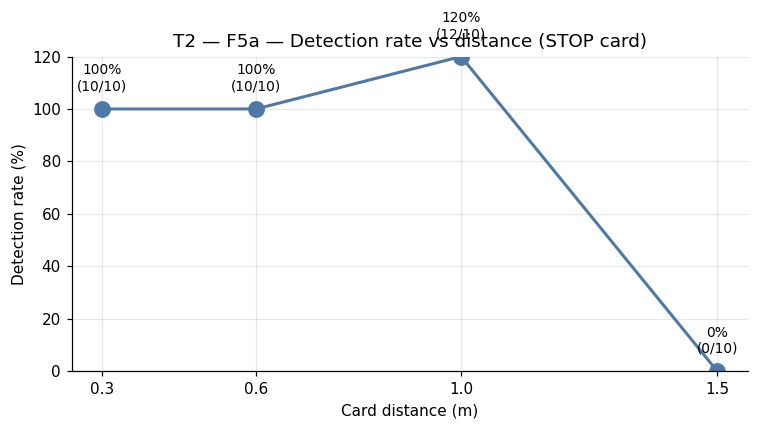

In [105]:
plot_t2 = summary_t2.copy()
for col in ['distance_m', 'detection_rate', 'reps_detected', 'reps_planned']:
    plot_t2[col] = pd.to_numeric(plot_t2[col], errors='coerce')
plot_t2 = plot_t2.dropna(subset=['distance_m', 'detection_rate', 'reps_detected', 'reps_planned']).copy()
assert not plot_t2.empty, 'No mapped T2 rows available to plot. Update BLOCK_DISTANCES / REPS_PER_BLOCK first.'

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    plot_t2['distance_m'], plot_t2['detection_rate'] * 100,
    marker='o', linewidth=2, markersize=10, color='#4e79a7',
)
for _, row in plot_t2.iterrows():
    pct = int(round(float(row['detection_rate']) * 100))
    detected = int(round(float(row['reps_detected'])))
    planned = int(round(float(row['reps_planned'])))
    ax.annotate(
        f"{pct}%\n({detected}/{planned})",
        (row['distance_m'], row['detection_rate'] * 100),
        textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9,
    )
ax.set_xlabel('Card distance (m)')
ax.set_ylabel('Detection rate (%)')
ax.set_title('T2 — F5a — Detection rate vs distance (STOP card)')
ax.set_ylim(0, 120)
ax.set_xticks(plot_t2['distance_m'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS / 't2_detection_rate.png', bbox_inches='tight')
plt.show()

### 3.7 — Figure: `bbox_area` vs distance (calibration sanity check)

Confirms the inverse-square relationship and gives the calibration data for the `min_bbox_area = 1500 px²` choice referenced in **IV.7** and the **T6 ablation**.

The red dashed line is the current `min_bbox_area` threshold — any distance whose bbox cluster sits *below* the line is one that the default filter would have rejected.

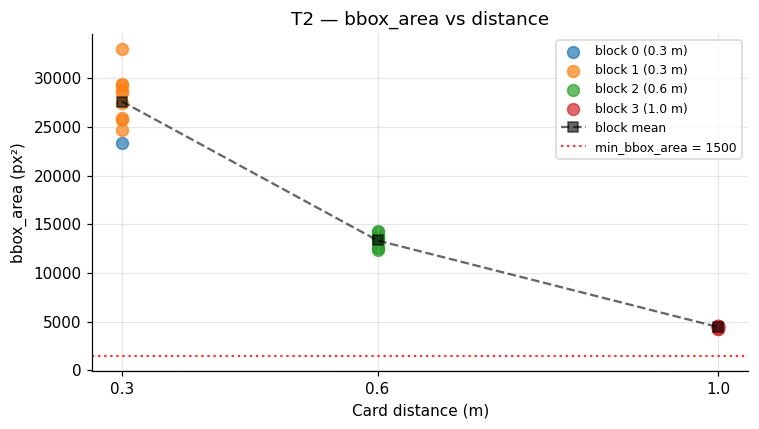

In [106]:
plot_bbox_t2 = summary_t2.copy()
for col in ['distance_m', 'bbox_mean']:
    plot_bbox_t2[col] = pd.to_numeric(plot_bbox_t2[col], errors='coerce')
plot_bbox_t2 = plot_bbox_t2.dropna(subset=['distance_m', 'bbox_mean']).copy()
assert not plot_bbox_t2.empty, 'No mapped T2 rows available to plot. Update BLOCK_DISTANCES first.'

fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.get_cmap('tab10')
for blk_idx, sub in events_t2.groupby('block'):
    d = BLOCK_DISTANCES.get(blk_idx)
    if d is None or sub['bbox_area'].isna().all():
        continue
    ax.scatter(
        [d] * len(sub), sub['bbox_area'],
        s=60, alpha=0.7, color=colors(blk_idx % 10),
        label=f'block {blk_idx} ({d} m)',
    )

ax.plot(
    plot_bbox_t2['distance_m'], plot_bbox_t2['bbox_mean'],
    marker='s', linestyle='--', color='black', alpha=0.6, label='block mean',
)
ax.axhline(1500, color='red', linestyle=':', alpha=0.8, label='min_bbox_area = 1500')

ax.set_xlabel('Card distance (m)')
ax.set_ylabel('bbox_area (px²)')
ax.set_title('T2 — bbox_area vs distance')
ax.set_xticks(plot_bbox_t2['distance_m'])
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
fig.savefig(FIGS / 't2_bbox_vs_distance.png', bbox_inches='tight')
plt.show()

### 3.8 — Figure: event timeline by inferred block

Visual sanity check on the block segmentation. The coloured spans show where the operator was at each distance mark; the empty gaps between them are the walk-to-next-mark pauses.

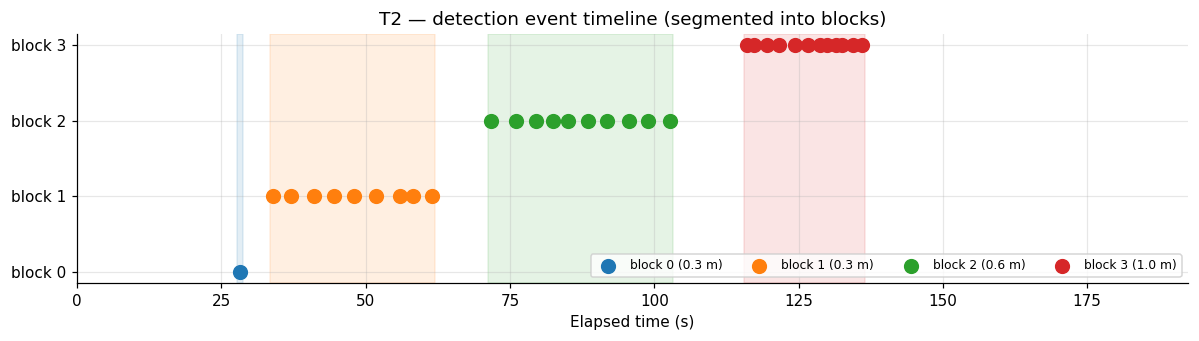

In [107]:
fig, ax = plt.subplots(figsize=(11, 3.2))
colors = plt.get_cmap('tab10')

for blk_idx, sub in events_t2.groupby('block'):
    d = BLOCK_DISTANCES.get(blk_idx)
    label = f'block {blk_idx}' + (f' ({d} m)' if d is not None else '')
    ax.scatter(
        sub['elapsed_s'], [blk_idx] * len(sub),
        s=80, color=colors(blk_idx % 10), label=label, zorder=3,
    )

for blk_idx, row in block_stats.iterrows():
    ax.axvspan(
        row['t_start'] - 0.5, row['t_end'] + 0.5,
        color=colors(blk_idx % 10), alpha=0.12,
    )

blocks_sorted = sorted(events_t2['block'].unique())
ax.set_yticks(blocks_sorted)
ax.set_yticklabels([f'block {b}' for b in blocks_sorted])
ax.set_xlabel('Elapsed time (s)')
ax.set_title('T2 — detection event timeline (segmented into blocks)')
ax.set_xlim(0, duration_t2)
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8, ncol=4, loc='lower right')
plt.tight_layout()
fig.savefig(FIGS / 't2_timeline.png', bbox_inches='tight')
plt.show()

## 4. T3 — Angle sweep

Drives **Figure F5b** and the V.2.2 angle subsection (also feeds the Stage-1 vs Stage-2 inline evidence in V.2.4 if `notes/trial3.md` records the decode stage per rep).

Mirrors the T2 §3 pipeline: load → events → block-segment → map blocks to angles → summary → chart. The angle is yaw (rotation about a vertical axis through the card stand) — see `phase-2-experiments.md:120` *"viewing angle (relative to camera normal)"*.


### 4.1 — Load T3 CSV

Picks the most recent `t3_angle_*.csv` from `repo/results/`.


In [108]:
if 'RESULTS' not in globals() or 'FIGS' not in globals():
    from pathlib import Path
    import json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    _here = Path.cwd()
    _repo_root = next(
        (p for p in [_here, *_here.parents]
         if (p / 'repo' / 'results').exists() or p.name.lower() == 'par-a3'),
        _here,
    )
    RESULTS = next(
        c for c in (_repo_root / 'repo' / 'results', _repo_root / 'results')
        if c.exists()
    )
    FIGS = RESULTS / 'figures'
    FIGS.mkdir(exist_ok=True)

t3_paths = sorted(RESULTS.glob('t3_angle_*.csv'))
assert t3_paths, f"No t3_angle_*.csv found in {RESULTS}"
T3_PATH = t3_paths[-1]
df_t3 = pd.read_csv(T3_PATH)
duration_t3 = df_t3['elapsed_s'].max()
print(f"Loaded {T3_PATH.name}")
print(f"  rows: {len(df_t3)}    duration: {duration_t3:.1f} s")
print(f"  detection_event=True rows: {int(df_t3['detection_event'].sum())}")


Loaded t3_angle_20260522_075134.csv
  rows: 638    duration: 127.6 s
  detection_event=True rows: 44


### 4.2 — Extract detection events + `bbox_area`

Same JSON-payload trick as T2 §3.2.


In [109]:
def _bbox_of_t3(s):
    """Pull bbox_area out of the first detection in the all_detections JSON."""
    try:
        items = json.loads(s)
        return items[0]['bbox_area'] if items else None
    except (TypeError, json.JSONDecodeError):
        return None

events_t3 = df_t3[df_t3['detection_event'] == True].copy()
events_t3['bbox_area'] = events_t3['all_detections'].apply(_bbox_of_t3)
events_t3 = events_t3[['elapsed_s', 'qr_command', 'bbox_area']].reset_index(drop=True)

print(f"detection events: {len(events_t3)}")
print(f"commands: {events_t3['qr_command'].value_counts().to_dict()}")
events_t3.round({'elapsed_s': 2, 'bbox_area': 0})


detection events: 44
commands: {'STOP': 44}


,elapsed_s,qr_command,bbox_area
0,10.23,STOP,6609.0
1,11.43,STOP,6966.0
2,12.63,STOP,6930.0
3,13.63,STOP,6937.0
4,15.03,STOP,7007.0
5,16.23,STOP,7007.0
6,17.43,STOP,6928.0
7,18.63,STOP,6928.0
8,20.23,STOP,7169.0
9,21.43,STOP,7049.0


### 4.3 — Auto-detect block boundaries

Same as T2: any inter-event gap > `BLOCK_GAP_S_T3` (default **5 s**) starts a new block. The operator's walk-back-to-protractor pause between angles is well over 5 s.


In [110]:
BLOCK_GAP_S_T3 = 5.0  # gap (s) that splits one angle block from the next

events_t3 = events_t3.sort_values('elapsed_s').reset_index(drop=True)
events_t3['gap_s'] = events_t3['elapsed_s'].diff()
events_t3['block'] = (events_t3['gap_s'].fillna(0) > BLOCK_GAP_S_T3).cumsum()

block_stats_t3 = events_t3.groupby('block').agg(
    n_events=('elapsed_s', 'count'),
    t_start=('elapsed_s', 'min'),
    t_end=('elapsed_s', 'max'),
    bbox_mean=('bbox_area', 'mean'),
    bbox_std=('bbox_area', 'std'),
    bbox_min=('bbox_area', 'min'),
    bbox_max=('bbox_area', 'max'),
)
block_stats_t3['duration_s'] = block_stats_t3['t_end'] - block_stats_t3['t_start']

print(f"Detected {len(block_stats_t3)} block(s) with BLOCK_GAP_S_T3 = {BLOCK_GAP_S_T3}s")
block_stats_t3.round(1)


Detected 5 block(s) with BLOCK_GAP_S_T3 = 5.0s


,n_events,t_start,t_end,bbox_mean,bbox_std,bbox_min,bbox_max,duration_s
block,,,,,,,,
0,12,10.2,25.0,6961.0,130.3,6608.6,7169.1,14.8
1,13,34.0,49.8,7720.8,70.7,7544.7,7877.1,15.8
2,13,62.2,80.8,6849.3,320.9,6445.9,7385.1,18.6
3,5,101.4,109.2,4635.7,123.7,4475.1,4819.1,7.8
4,1,115.8,115.8,4294.6,NaN,4294.6,4294.6,0.0


### 4.4 — Map blocks → angles + build summary

**Edit `BLOCK_ANGLES`** to match `notes/trial3.md`. Default assumes the planned order (0° → 15° → 30° → 45°). Sanity check is the bbox_mean column above: bbox shrinks as the QR is yawed away from the camera (foreshortening), so larger bbox = smaller angle. For small angles (15°) the change is only ~3% (cos 15° ≈ 0.97) so don't read too much into it; the 30° → 45° step is where the cliff usually shows.

**Edit `REPS_PER_BLOCK_T3`** if any block was stopped short or ran long. The detector enforces a 1.0 s per-command cooldown, so events ≈ unique reps as long as the operator withdrew the card cleanly within 1 s. If a block reports > 10 events, you either presented > 10 times or held the card up too long and the cooldown re-fired (runbook §2.5 step 5 calls this out).

`ZERO_DETECTION_ANGLES` covers angles where the operator attempted reps but the detector never fired (needed at 45° if the cliff is hard) — these can't be inferred from `events_t3` because zero-event blocks have no rows.


In [111]:
# --- EDIT THESE THREE DICTS TO MATCH notes/trial3.md ---
# Mapping for t3_angle_20260522_075134.csv:
#   Block 0 (12 events, bbox~6900) → 0° (over-count by 2, see runbook §2.5 step 5)
#   Block 1 (13 events, bbox~7700) → 15° (over-count by 3; bbox slightly larger,
#     likely operator nudged the card forward when re-aiming through the protractor)
#   Block 2 (12 events, bbox~6900→6400) → 30° (over-count by 2)
#   Block 3 (5 events, bbox~4500) → 45° (5/10 detected; clear cliff)
#   Block 4 (1 stray event after 6.6 s pause, bbox~4300) → still 45°
#     (the segmenter split 45° because the operator paused mid-block;
#      its 1 detection rolls into the 45° total via planned=0)
BLOCK_ANGLES = {  # block index → angle (deg)
    0: 0,
    1: 15,
    2: 30,
    3: 45,
    4: 45,
}
REPS_PER_BLOCK_T3 = {  # how many attempts you actually made in each inferred block
    0: 10,
    1: 10,
    2: 10,
    3: 10,
    4: 0,   # stray after the planned 10-rep 45° block — no extra planned reps
}
ZERO_DETECTION_ANGLES = {  # angle (deg) → reps_planned, for angles with 0 detections
    # 45: 10,   # uncomment if you push to 60°/75° in a future run and it cliffs to 0
}
# -------------------------------------------------------

block_meta_t3 = block_stats_t3.copy()
block_meta_t3['angle_deg']    = block_meta_t3.index.map(BLOCK_ANGLES)
block_meta_t3['reps_planned'] = block_meta_t3.index.map(REPS_PER_BLOCK_T3)
block_meta_t3['reps_detected'] = block_meta_t3['n_events']

unmapped_blocks_t3 = block_meta_t3[block_meta_t3['angle_deg'].isna()].copy()
if not unmapped_blocks_t3.empty:
    print('Warning: unmapped T3 blocks — excluding until BLOCK_ANGLES is updated:')
    cols = ['reps_detected', 't_start', 't_end', 'bbox_mean', 'bbox_std']
    print(unmapped_blocks_t3[cols].round(1).to_string())

mapped_blocks_t3 = block_meta_t3[block_meta_t3['angle_deg'].notna()].copy()
missing_reps_t3 = mapped_blocks_t3[mapped_blocks_t3['reps_planned'].isna()]
if not missing_reps_t3.empty:
    missing_ids = ', '.join(str(int(i)) for i in missing_reps_t3.index)
    raise ValueError(f'Add REPS_PER_BLOCK_T3 entries for mapped block(s): {missing_ids}')

assert not mapped_blocks_t3.empty, 'No T3 blocks are mapped to angles. Update BLOCK_ANGLES first.'

mapped_events_t3 = events_t3[events_t3['block'].isin(mapped_blocks_t3.index)].copy()
mapped_events_t3['angle_deg'] = mapped_events_t3['block'].map(BLOCK_ANGLES)

summary_detected_t3 = mapped_events_t3.groupby('angle_deg').agg(
    reps_detected=('elapsed_s', 'count'),
    bbox_mean=('bbox_area', 'mean'),
    bbox_std=('bbox_area', 'std'),
    bbox_min=('bbox_area', 'min'),
    bbox_max=('bbox_area', 'max'),
)
summary_planned_t3 = mapped_blocks_t3.groupby('angle_deg')['reps_planned'].sum()

summary_t3 = summary_detected_t3.join(summary_planned_t3, how='left').reset_index()
summary_t3['detection_rate'] = summary_t3['reps_detected'] / summary_t3['reps_planned']
summary_t3 = summary_t3[['angle_deg', 'reps_detected', 'reps_planned',
                          'bbox_mean', 'bbox_std', 'bbox_min', 'bbox_max',
                          'detection_rate']]

# Inject angles where the operator attempted reps but got zero detections.
for _zero_a, _zero_n in ZERO_DETECTION_ANGLES.items():
    if _zero_a in summary_t3['angle_deg'].values:
        continue
    summary_t3.loc[len(summary_t3)] = {
        'angle_deg': _zero_a,
        'reps_detected': 0,
        'reps_planned': _zero_n,
        'bbox_mean': float('nan'),
        'bbox_std': float('nan'),
        'bbox_min': float('nan'),
        'bbox_max': float('nan'),
        'detection_rate': 0.0,
    }
summary_t3 = summary_t3.sort_values('angle_deg').reset_index(drop=True)

print('T3 per-block mapping:')
print(block_meta_t3[['reps_detected', 'angle_deg', 'reps_planned', 'bbox_mean', 'bbox_std']]
      .round({'bbox_mean': 0, 'bbox_std': 0}).to_string())
print('\nT3 per-angle summary:')
summary_t3.round({'bbox_mean': 0, 'bbox_std': 0, 'bbox_min': 0, 'bbox_max': 0, 'detection_rate': 2})


T3 per-block mapping:
       reps_detected  angle_deg  reps_planned  bbox_mean  bbox_std
block                                                             
0                 12          0            10     6961.0     130.0
1                 13         15            10     7721.0      71.0
2                 13         30            10     6849.0     321.0
3                  5         45            10     4636.0     124.0
4                  1         45             0     4295.0       NaN

T3 per-angle summary:


,angle_deg,reps_detected,reps_planned,bbox_mean,bbox_std,bbox_min,bbox_max,detection_rate
0,0,12,10,6961.0,130.0,6609.0,7169.0,1.2
1,15,13,10,7721.0,71.0,7545.0,7877.0,1.3
2,30,13,10,6849.0,321.0,6446.0,7385.0,1.3
3,45,6,10,4579.0,178.0,4295.0,4819.0,0.6


### 4.5 — Export `t3_summary.csv`

Feeds the V.2.2 angle results table.


In [112]:
out_t3 = RESULTS / 't3_summary.csv'
summary_t3.to_csv(out_t3, index=False)
print(f"wrote {out_t3}")
summary_t3.round({'bbox_mean': 0, 'bbox_std': 0, 'bbox_min': 0, 'bbox_max': 0, 'detection_rate': 2})


wrote /Users/lintran/Documents/Coding/PAR-A3/repo/results/t3_summary.csv


,angle_deg,reps_detected,reps_planned,bbox_mean,bbox_std,bbox_min,bbox_max,detection_rate
0,0,12,10,6961.0,130.0,6609.0,7169.0,1.2
1,15,13,10,7721.0,71.0,7545.0,7877.0,1.3
2,30,13,10,6849.0,321.0,6446.0,7385.0,1.3
3,45,6,10,4579.0,178.0,4295.0,4819.0,0.6


### 4.6 — Figure F5b: detection rate vs angle

The headline T3 figure. Annotations show `detected / planned`. Detection rates above 100 % are a flag that the operator either presented more than 10 times or held the card up past the 1.0 s cooldown — record the cause in `notes/trial3.md`.


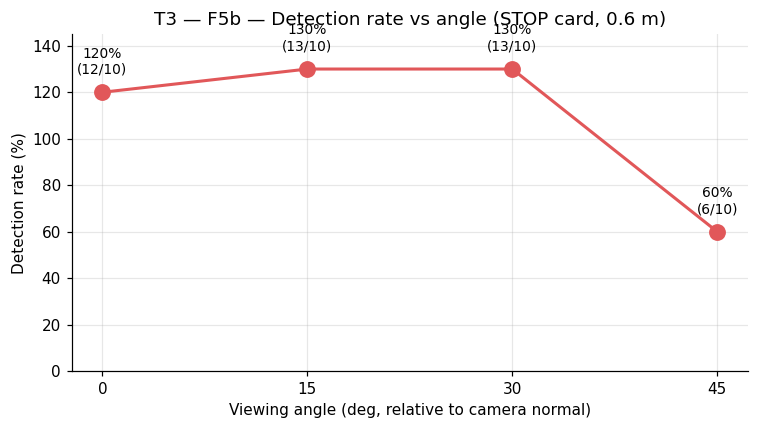

In [113]:
plot_t3 = summary_t3.copy()
for col in ['angle_deg', 'detection_rate', 'reps_detected', 'reps_planned']:
    plot_t3[col] = pd.to_numeric(plot_t3[col], errors='coerce')
plot_t3 = plot_t3.dropna(subset=['angle_deg', 'detection_rate', 'reps_detected', 'reps_planned']).copy()
assert not plot_t3.empty, 'No mapped T3 rows available to plot. Update BLOCK_ANGLES / REPS_PER_BLOCK_T3 first.'

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    plot_t3['angle_deg'], plot_t3['detection_rate'] * 100,
    marker='o', linewidth=2, markersize=10, color='#e15759',
)
for _, row in plot_t3.iterrows():
    pct = int(round(float(row['detection_rate']) * 100))
    detected = int(round(float(row['reps_detected'])))
    planned = int(round(float(row['reps_planned'])))
    ax.annotate(
        f"{pct}%\n({detected}/{planned})",
        (row['angle_deg'], row['detection_rate'] * 100),
        textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9,
    )
ax.set_xlabel('Viewing angle (deg, relative to camera normal)')
ax.set_ylabel('Detection rate (%)')
ax.set_title('T3 — F5b — Detection rate vs angle (STOP card, 0.6 m)')
_y_top = max(135.0, float(plot_t3['detection_rate'].max()) * 100 + 15)
ax.set_ylim(0, _y_top)
ax.set_xticks(plot_t3['angle_deg'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS / 't3_detection_rate.png', bbox_inches='tight')
plt.show()


### 4.7 — Figure: `bbox_area` vs angle (sanity check)

Foreshortening should monotonically shrink `bbox_area` as the angle grows, by roughly `cos(angle)` (small effect at 15°, ~30 % loss by 45°). If your blocks don't follow that trend, the BLOCK_ANGLES mapping is probably wrong, or the operator nudged the card distance between blocks.


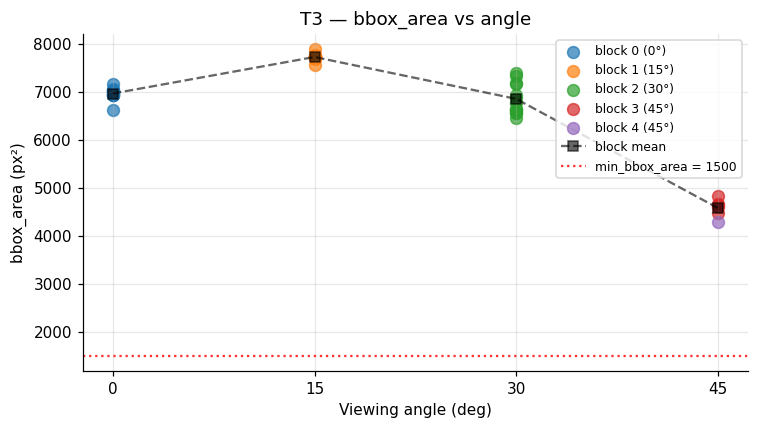

In [114]:
plot_bbox_t3 = summary_t3.copy()
for col in ['angle_deg', 'bbox_mean']:
    plot_bbox_t3[col] = pd.to_numeric(plot_bbox_t3[col], errors='coerce')
plot_bbox_t3 = plot_bbox_t3.dropna(subset=['angle_deg', 'bbox_mean']).copy()
assert not plot_bbox_t3.empty, 'No mapped T3 rows available to plot. Update BLOCK_ANGLES first.'

fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.get_cmap('tab10')
for blk_idx, sub in events_t3.groupby('block'):
    a = BLOCK_ANGLES.get(blk_idx)
    if a is None or sub['bbox_area'].isna().all():
        continue
    ax.scatter(
        [a] * len(sub), sub['bbox_area'],
        s=60, alpha=0.7, color=colors(blk_idx % 10),
        label=f'block {blk_idx} ({a}°)',
    )

ax.plot(
    plot_bbox_t3['angle_deg'], plot_bbox_t3['bbox_mean'],
    marker='s', linestyle='--', color='black', alpha=0.6, label='block mean',
)
ax.axhline(1500, color='red', linestyle=':', alpha=0.8, label='min_bbox_area = 1500')

ax.set_xlabel('Viewing angle (deg)')
ax.set_ylabel('bbox_area (px²)')
ax.set_title('T3 — bbox_area vs angle')
ax.set_xticks(plot_bbox_t3['angle_deg'])
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
fig.savefig(FIGS / 't3_bbox_vs_angle.png', bbox_inches='tight')
plt.show()


### 4.8 — Figure: event timeline by inferred block

Visual sanity check on segmentation — same as T2 §3.8 but for angle blocks. Coloured spans show where the operator was at each protractor mark; the gaps are the re-aim pauses.


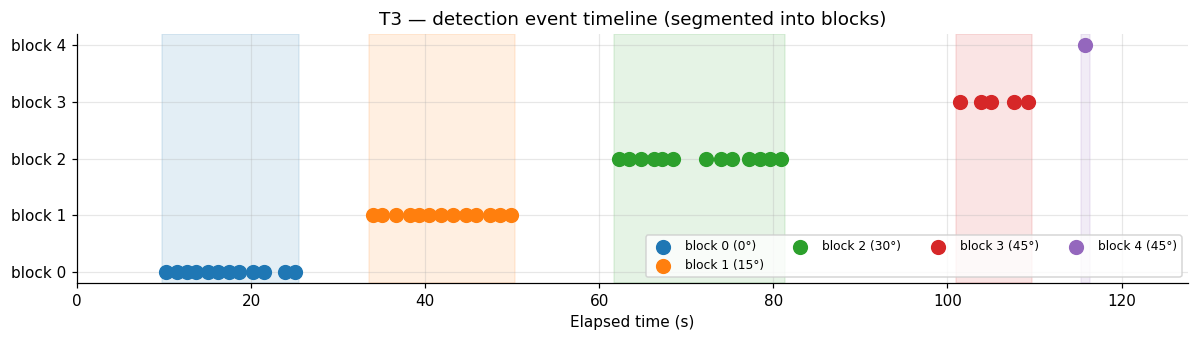

In [115]:
fig, ax = plt.subplots(figsize=(11, 3.2))
colors = plt.get_cmap('tab10')

for blk_idx, sub in events_t3.groupby('block'):
    a = BLOCK_ANGLES.get(blk_idx)
    label = f'block {blk_idx}' + (f' ({a}°)' if a is not None else '')
    ax.scatter(
        sub['elapsed_s'], [blk_idx] * len(sub),
        s=80, color=colors(blk_idx % 10), label=label, zorder=3,
    )

for blk_idx, row in block_stats_t3.iterrows():
    ax.axvspan(
        row['t_start'] - 0.5, row['t_end'] + 0.5,
        color=colors(blk_idx % 10), alpha=0.12,
    )

blocks_sorted = sorted(events_t3['block'].unique())
ax.set_yticks(blocks_sorted)
ax.set_yticklabels([f'block {b}' for b in blocks_sorted])
ax.set_xlabel('Elapsed time (s)')
ax.set_title('T3 — detection event timeline (segmented into blocks)')
ax.set_xlim(0, duration_t3)
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8, ncol=4, loc='lower right')
plt.tight_layout()
fig.savefig(FIGS / 't3_timeline.png', bbox_inches='tight')
plt.show()


## 5. T4 — Lighting variation

Drives the V.2.2 lighting subsection — empirical evidence for the CLAHE preprocessing claim. Three illumination conditions × 10 reps each (`phase-2-runbook.md` §3.4):

| Block | Condition | Setup |
|---|---|---|
| 1 | **Bright** (~500 lux) | All overhead lights on. |
| 2 | **Normal** (~250 lux) | Half overhead lights on. |
| 3 | **Dim** (~50 lux) | One lamp only. Card still legible to the eye. |

STOP card at 0.6 m, 0° — fixed across blocks. Same auto-segmentation and 1.0 s cooldown rules as T2/T3. Two new operator-override knobs because T4 is the first trial where `bbox_area` is *not* a physical sanity check (lighting doesn't move the card), so the only way to flag warmups / cooldown re-fires is the operator's own notes:

- `WARMUP_SKIP_T4`  — skip the first N detections of a block (e.g. card was at the wrong mark before being moved into position).
- `REFIRE_DEDUP_T4` — drop N consecutive detections within < 1.5 s of their predecessor (cooldown re-fires from holding the card past 1 s; runbook §2.5 step 5).

Operator notes for `t4_lighting_20260522_083408.csv` (recorded in chat / `notes/trial4.md`):
- **Block 0 (Bright)** — 12 detections; the first 3 (t=41–45 s, `bbox≈4 800`) were at the wrong distance mark, then operator moved the card at t≈48 s. Skip the first 3 → 9 detections.
- **Block 1 (Normal)** — 11 detections; held card past the 1.0 s cooldown once → de-dup 1 → 10 detections.
- **Block 2 (Dim)** — 10 detections, no overrides.
- **Block 3** — single stray detection at t=159.8 s, `bbox≈28 000`. The bbox matches a card held at ~0.3 m (T2 calibration), 27 s after the Dim block ended — most likely an end-of-session sanity check. Excluded by setting `BLOCK_LIGHTING[3] = None`. Flip to a real condition if your `notes/trial4.md` says otherwise.

### 5.1 — Load T4 CSV

Picks the most recent `t4_lighting_*.csv` from `repo/results/`.

In [116]:
if 'RESULTS' not in globals() or 'FIGS' not in globals():
    from pathlib import Path
    import json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    _here = Path.cwd()
    _repo_root = next(
        (p for p in [_here, *_here.parents]
         if (p / 'repo' / 'results').exists() or p.name.lower() == 'par-a3'),
        _here,
    )
    RESULTS = next(
        c for c in (_repo_root / 'repo' / 'results', _repo_root / 'results')
        if c.exists()
    )
    FIGS = RESULTS / 'figures'
    FIGS.mkdir(exist_ok=True)

t4_paths = sorted(RESULTS.glob('t4_lighting_*.csv'))
assert t4_paths, f"No t4_lighting_*.csv found in {RESULTS}"
T4_PATH = t4_paths[-1]
df_t4 = pd.read_csv(T4_PATH)
duration_t4 = df_t4['elapsed_s'].max()
print(f"Loaded {T4_PATH.name}")
print(f"  rows: {len(df_t4)}    duration: {duration_t4:.1f} s")
print(f"  detection_event=True rows: {int(df_t4['detection_event'].sum())}")

Loaded t4_lighting_20260522_083408.csv
  rows: 837    duration: 167.4 s
  detection_event=True rows: 35


### 5.2 — Extract detection events + `bbox_area`

Same JSON-payload trick as T2 §3.2. Drop rows where the JSON failed to parse (rare — usually a logger flush mid-row).

In [117]:
def _bbox_of_t4(s):
    """Pull bbox_area out of the first detection in the all_detections JSON."""
    try:
        items = json.loads(s)
        return items[0]['bbox_area'] if items else None
    except (TypeError, json.JSONDecodeError):
        return None

events_t4 = df_t4[df_t4['detection_event'] == True].copy()
events_t4['bbox_area'] = events_t4['all_detections'].apply(_bbox_of_t4)
_n_dropped = int(events_t4['bbox_area'].isna().sum())
if _n_dropped:
    print(f"dropped {_n_dropped} detection row(s) with unparseable JSON")
events_t4 = events_t4.dropna(subset=['bbox_area']).copy()
events_t4 = events_t4[['elapsed_s', 'qr_command', 'bbox_area']].reset_index(drop=True)

print(f"detection events: {len(events_t4)}")
print(f"commands: {events_t4['qr_command'].value_counts().to_dict()}")
events_t4.round({'elapsed_s': 2, 'bbox_area': 0})

dropped 1 detection row(s) with unparseable JSON
detection events: 34
commands: {'STOP': 34}


,elapsed_s,qr_command,bbox_area
0,41.42,STOP,4614.0
1,43.22,STOP,4793.0
2,45.42,STOP,5066.0
3,48.82,STOP,9728.0
4,50.02,STOP,9283.0
5,51.02,STOP,9451.0
6,52.22,STOP,9787.0
7,53.42,STOP,9738.0
8,54.62,STOP,9740.0
9,55.62,STOP,9731.0


### 5.3 — Auto-detect block boundaries

Same as T2/T3: any inter-event gap > `BLOCK_GAP_S_T4` (default **5 s**) starts a new block. The operator's pause to toggle the lights between conditions is well over 5 s.

In [118]:
BLOCK_GAP_S_T4 = 5.0  # gap (s) that splits one lighting block from the next

events_t4 = events_t4.sort_values('elapsed_s').reset_index(drop=True)
events_t4['gap_s'] = events_t4['elapsed_s'].diff()
events_t4['block'] = (events_t4['gap_s'].fillna(0) > BLOCK_GAP_S_T4).cumsum()

block_stats_t4 = events_t4.groupby('block').agg(
    n_events=('elapsed_s', 'count'),
    t_start=('elapsed_s', 'min'),
    t_end=('elapsed_s', 'max'),
    bbox_mean=('bbox_area', 'mean'),
    bbox_std=('bbox_area', 'std'),
    bbox_min=('bbox_area', 'min'),
    bbox_max=('bbox_area', 'max'),
)
block_stats_t4['duration_s'] = block_stats_t4['t_end'] - block_stats_t4['t_start']

print(f"Detected {len(block_stats_t4)} block(s) with BLOCK_GAP_S_T4 = {BLOCK_GAP_S_T4}s")
block_stats_t4.round(1)

Detected 4 block(s) with BLOCK_GAP_S_T4 = 5.0s


,n_events,t_start,t_end,bbox_mean,bbox_std,bbox_min,bbox_max,duration_s
block,,,,,,,,
0,12,41.4,57.8,8447.0,2191.5,4614.2,9787.3,16.4
1,11,72.2,83.8,8268.9,322.2,7452.7,8666.6,11.6
2,10,118.4,132.6,10038.5,1162.7,7636.0,11354.8,14.2
3,1,159.8,159.8,27968.8,NaN,27968.8,27968.8,0.0


### 5.4 — Map blocks → conditions, apply overrides, build summary

`BLOCK_LIGHTING` maps each inferred block to a condition name (or `None` to exclude). `WARMUP_SKIP_T4` and `REFIRE_DEDUP_T4` are the post-segmentation cleaning knobs documented in §5 above. The cell prints both **raw** and **cleaned** detection counts so you can audit each override before trusting the per-condition summary.

In [119]:
# --- EDIT THESE FOUR DICTS TO MATCH notes/trial4.md ---
# Operator notes for t4_lighting_20260522_083408.csv:
#   Block 0 → Bright. First 3 detections (bbox~4800) were at the wrong distance
#     mark; operator moved the card at t≈48s. Skip those 3 via WARMUP_SKIP_T4.
#   Block 1 → Normal. Held card past 1.0s cooldown once → 1 spurious re-fire,
#     deduped via REFIRE_DEDUP_T4.
#   Block 2 → Dim. Clean.
#   Block 3 → stray (single event, bbox~28000 → matches 0.3 m close-up,
#     27 s after Dim block ended). Excluded by setting BLOCK_LIGHTING[3]=None.
BLOCK_LIGHTING = {  # block index → lighting condition (None to exclude)
    0: 'Bright',
    1: 'Normal',
    2: 'Dim',
    3: None,
}
REPS_PER_BLOCK_T4 = {  # how many attempts you actually made in each MAPPED block
    0: 10,
    1: 10,
    2: 10,
    # No entry for block 3 because BLOCK_LIGHTING[3] is None (excluded).
}
WARMUP_SKIP_T4 = {  # block index → drop the first N detections of that block
    0: 3,
}
REFIRE_DEDUP_T4 = {  # block index → drop N detections that came < 1.5 s after the prior one
    1: 1,
}
# -------------------------------------------------------

LIGHTING_ORDER = ['Bright', 'Normal', 'Dim']  # canonical x-axis order for the chart

# Apply WARMUP_SKIP_T4 then REFIRE_DEDUP_T4 to events_t4 → cleaned_events_t4.
_cleaned_frames = []
for _blk, _sub in events_t4.groupby('block'):
    _sub = _sub.sort_values('elapsed_s').reset_index(drop=True)
    _sk = WARMUP_SKIP_T4.get(_blk, 0)
    if _sk > 0:
        _sub = _sub.iloc[_sk:].copy()
    _dd = REFIRE_DEDUP_T4.get(_blk, 0)
    if _dd > 0 and len(_sub) > 1:
        _keep = [True] * len(_sub)
        _removed = 0
        for _i in range(1, len(_sub)):
            if _removed >= _dd:
                break
            if _sub.iloc[_i]['elapsed_s'] - _sub.iloc[_i - 1]['elapsed_s'] < 1.5:
                _keep[_i] = False
                _removed += 1
        _sub = _sub.loc[_keep].copy()
    _cleaned_frames.append(_sub)
cleaned_events_t4 = (
    pd.concat(_cleaned_frames, ignore_index=True)
    if _cleaned_frames else events_t4.iloc[0:0].copy()
)
cleaned_events_t4['lighting'] = cleaned_events_t4['block'].map(BLOCK_LIGHTING)

block_meta_t4 = block_stats_t4.copy()
block_meta_t4['lighting']           = block_meta_t4.index.map(BLOCK_LIGHTING)
block_meta_t4['reps_planned']       = block_meta_t4.index.map(REPS_PER_BLOCK_T4)
block_meta_t4['reps_detected_raw']  = block_meta_t4['n_events']
block_meta_t4['reps_detected']      = (
    cleaned_events_t4.groupby('block').size()
    .reindex(block_stats_t4.index, fill_value=0)
)

unmapped_blocks_t4 = block_meta_t4[block_meta_t4['lighting'].isna()].copy()
if not unmapped_blocks_t4.empty:
    print('Excluded T4 blocks (BLOCK_LIGHTING[idx] is None or unset):')
    cols = ['reps_detected_raw', 't_start', 't_end', 'bbox_mean', 'bbox_std']
    print(unmapped_blocks_t4[cols].round(1).to_string())

mapped_blocks_t4 = block_meta_t4[block_meta_t4['lighting'].notna()].copy()
missing_reps_t4 = mapped_blocks_t4[mapped_blocks_t4['reps_planned'].isna()]
if not missing_reps_t4.empty:
    missing_ids = ', '.join(str(int(i)) for i in missing_reps_t4.index)
    raise ValueError(f'Add REPS_PER_BLOCK_T4 entries for mapped block(s): {missing_ids}')

assert not mapped_blocks_t4.empty, 'No T4 blocks mapped to lighting conditions. Update BLOCK_LIGHTING first.'

mapped_events_t4 = cleaned_events_t4[cleaned_events_t4['lighting'].notna()].copy()

summary_detected_t4 = mapped_events_t4.groupby('lighting').agg(
    reps_detected=('elapsed_s', 'count'),
    bbox_mean=('bbox_area', 'mean'),
    bbox_std=('bbox_area', 'std'),
    bbox_min=('bbox_area', 'min'),
    bbox_max=('bbox_area', 'max'),
)
summary_planned_t4 = mapped_blocks_t4.groupby('lighting')['reps_planned'].sum()

summary_t4 = summary_detected_t4.join(summary_planned_t4, how='left').reset_index()
summary_t4['detection_rate'] = summary_t4['reps_detected'] / summary_t4['reps_planned']
summary_t4 = summary_t4[['lighting', 'reps_detected', 'reps_planned',
                          'bbox_mean', 'bbox_std', 'bbox_min', 'bbox_max',
                          'detection_rate']]

# Order rows by canonical lighting order (Bright → Normal → Dim).
_present = [c for c in LIGHTING_ORDER if c in summary_t4['lighting'].values]
_extra = [c for c in summary_t4['lighting'].values if c not in LIGHTING_ORDER]
summary_t4 = (
    summary_t4.set_index('lighting').loc[_present + _extra].reset_index()
)

print('T4 per-block mapping (raw vs cleaned reps_detected):')
print(block_meta_t4[['lighting', 'reps_planned', 'reps_detected_raw', 'reps_detected', 'bbox_mean']]
      .round({'bbox_mean': 0}).to_string())
print('\nT4 per-condition summary:')
summary_t4.round({'bbox_mean': 0, 'bbox_std': 0, 'bbox_min': 0, 'bbox_max': 0, 'detection_rate': 2})

Excluded T4 blocks (BLOCK_LIGHTING[idx] is None or unset):
       reps_detected_raw  t_start  t_end  bbox_mean  bbox_std
block                                                        
3                      1    159.8  159.8    27968.8       NaN
T4 per-block mapping (raw vs cleaned reps_detected):
      lighting  reps_planned  reps_detected_raw  reps_detected  bbox_mean
block                                                                    
0       Bright          10.0                 12              9     8447.0
1       Normal          10.0                 11             10     8269.0
2          Dim          10.0                 10             10    10038.0
3          NaN           NaN                  1              1    27969.0

T4 per-condition summary:


,lighting,reps_detected,reps_planned,bbox_mean,bbox_std,bbox_min,bbox_max,detection_rate
0,Bright,9,10.0,9655.0,171.0,9283.0,9787.0,0.9
1,Normal,10,10.0,8269.0,340.0,7453.0,8667.0,1.0
2,Dim,10,10.0,10038.0,1163.0,7636.0,11355.0,1.0


### 5.5 — Export `t4_summary.csv`

Feeds the V.2.2 lighting inline table.

In [120]:
out_t4 = RESULTS / 't4_summary.csv'
summary_t4.to_csv(out_t4, index=False)
print(f"wrote {out_t4}")
summary_t4.round({'bbox_mean': 0, 'bbox_std': 0, 'bbox_min': 0, 'bbox_max': 0, 'detection_rate': 2})

wrote /Users/lintran/Documents/Coding/PAR-A3/repo/results/t4_summary.csv


,lighting,reps_detected,reps_planned,bbox_mean,bbox_std,bbox_min,bbox_max,detection_rate
0,Bright,9,10.0,9655.0,171.0,9283.0,9787.0,0.9
1,Normal,10,10.0,8269.0,340.0,7453.0,8667.0,1.0
2,Dim,10,10.0,10038.0,1163.0,7636.0,11355.0,1.0


### 5.6 — Figure: detection rate vs lighting condition

Bar chart instead of a line chart since the conditions are categorical, not numeric. Annotations show `detected / planned`. A rate above 100% would be a cooldown re-fire that survived `REFIRE_DEDUP_T4` (i.e. an extra adjustment for `notes/trial4.md`).

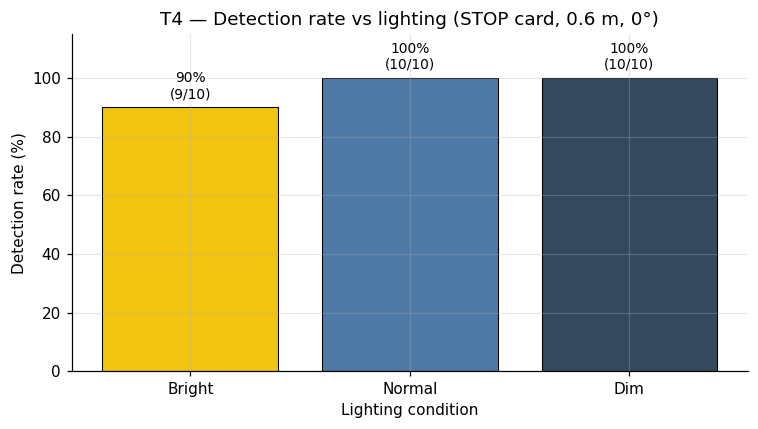

In [121]:
plot_t4 = summary_t4.copy()
for col in ['detection_rate', 'reps_detected', 'reps_planned']:
    plot_t4[col] = pd.to_numeric(plot_t4[col], errors='coerce')
plot_t4 = plot_t4.dropna(subset=['detection_rate', 'reps_detected', 'reps_planned']).copy()
assert not plot_t4.empty, 'No mapped T4 rows available to plot. Update BLOCK_LIGHTING first.'

bar_colors = {'Bright': '#f1c40f', 'Normal': '#4e79a7', 'Dim': '#34495e'}

fig, ax = plt.subplots(figsize=(7, 4))
xs = list(range(len(plot_t4)))
ax.bar(
    xs, (plot_t4['detection_rate'] * 100).tolist(),
    color=[bar_colors.get(c, '#888') for c in plot_t4['lighting']],
    edgecolor='black', linewidth=0.7,
)
for x, row in zip(xs, plot_t4.itertuples(index=False)):
    pct = int(round(float(row.detection_rate) * 100))
    detected = int(round(float(row.reps_detected)))
    planned = int(round(float(row.reps_planned)))
    ax.annotate(
        f"{pct}%\n({detected}/{planned})",
        (x, row.detection_rate * 100),
        textcoords='offset points', xytext=(0, 6), ha='center', fontsize=9,
    )

ax.set_xticks(xs)
ax.set_xticklabels(plot_t4['lighting'])
ax.set_xlabel('Lighting condition')
ax.set_ylabel('Detection rate (%)')
ax.set_title('T4 — Detection rate vs lighting (STOP card, 0.6 m, 0°)')
_y_top = max(115.0, float(plot_t4['detection_rate'].max()) * 100 + 15)
ax.set_ylim(0, _y_top)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS / 't4_detection_rate.png', bbox_inches='tight')
plt.show()

### 5.7 — Figure: event timeline by inferred block

Visual sanity check on segmentation — same as T2 §3.8 / T3 §4.8 but for lighting blocks. Coloured spans show where the operator was at each illumination level; the gaps are the light-toggle pauses. Excluded blocks (e.g. block 3 stray) are still drawn so you can spot anomalies.

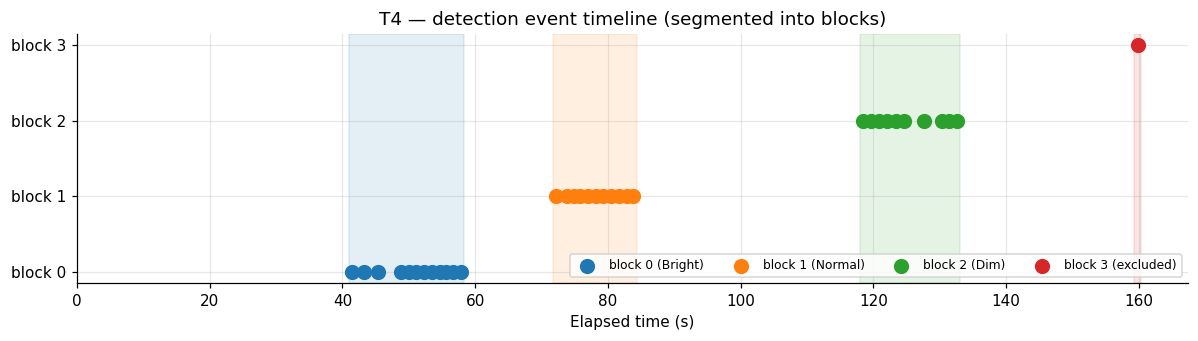

In [122]:
fig, ax = plt.subplots(figsize=(11, 3.2))
colors = plt.get_cmap('tab10')

for blk_idx, sub in events_t4.groupby('block'):
    label_cond = BLOCK_LIGHTING.get(blk_idx)
    label = f'block {blk_idx}' + (f' ({label_cond})' if label_cond else ' (excluded)')
    ax.scatter(
        sub['elapsed_s'], [blk_idx] * len(sub),
        s=80, color=colors(blk_idx % 10), label=label, zorder=3,
    )

for blk_idx, row in block_stats_t4.iterrows():
    ax.axvspan(
        row['t_start'] - 0.5, row['t_end'] + 0.5,
        color=colors(blk_idx % 10), alpha=0.12,
    )

blocks_sorted = sorted(events_t4['block'].unique())
ax.set_yticks(blocks_sorted)
ax.set_yticklabels([f'block {b}' for b in blocks_sorted])
ax.set_xlabel('Elapsed time (s)')
ax.set_title('T4 — detection event timeline (segmented into blocks)')
ax.set_xlim(0, duration_t4)
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8, ncol=4, loc='lower right')
plt.tight_layout()
fig.savefig(FIGS / 't4_timeline.png', bbox_inches='tight')
plt.show()

## 6. T5 — Simultaneous QR (closer-card-wins)

Drives V.2.3 and the C1 *Excellent* rubric line. **The rubric:** when two QR cards land in the same frame, the publisher must pick the one with the **larger `bbox_area`** (i.e. the closer card). The detector implements this as `argmax(bbox_area)` over all decoded payloads in a frame (`qr_detector_node.py`); T5 is the empirical proof that the tie-break works.

Setup (`phase-2-runbook.md` §3.5): two cards on stands at ~0.4 m (closer) and ~0.8 m (further), 10 trials. Vary the pair occasionally so the result isn't accidentally hard-coded to one command.

#### What "a trial" means in this CSV

The data logger writes one row per camera frame; the QR detector is rate-limited by the 1.0 s per-command cooldown. So a *physical* trial (hold both cards, observe published command, withdraw) typically produces one or more cooldown-cleared rows depending on how long the cards stayed in frame. We don't need to collapse them — the rubric is **per-frame**: every dual-card frame is an independent "two cards seen, who wins?" decision.

#### Frame taxonomy

Every `detection_event=True` row falls into one of:
- **Dual-card frame** — `len(all_detections) ≥ 2`. *This is what counts toward the rubric.* `qr_command` records who won; `argmax(bbox_area)` over the JSON list tells us who *should* have won.
- **Single-card frame** — `len(all_detections) == 1`. Only one card was decoded in that frame, so the closer-wins question is moot. Reported separately as context (warmups / between-trial card flashes).

For `t5_simultaneous_20260522_093952.csv` (per the operator-clarification chat): the actual T5 protocol was the contiguous **U_TURN (closer) + SPEED_DOWN (further)** block at t≈43–65 s. The other single-card detections (GO, TURN_LEFT, SPEED_UP, STOP, etc., all at close range) were warmups — operator confirmed each card decodes individually before running the dual-card test.

### 6.1 — Load T5 CSV

Picks the most recent `t5_simultaneous_*.csv` from `repo/results/`.

In [123]:
if 'RESULTS' not in globals() or 'FIGS' not in globals():
    from pathlib import Path
    import json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    _here = Path.cwd()
    _repo_root = next(
        (p for p in [_here, *_here.parents]
         if (p / 'repo' / 'results').exists() or p.name.lower() == 'par-a3'),
        _here,
    )
    RESULTS = next(
        c for c in (_repo_root / 'repo' / 'results', _repo_root / 'results')
        if c.exists()
    )
    FIGS = RESULTS / 'figures'
    FIGS.mkdir(exist_ok=True)

t5_paths = sorted(RESULTS.glob('t5_simultaneous_*.csv'))
assert t5_paths, f"No t5_simultaneous_*.csv found in {RESULTS}"
T5_PATH = t5_paths[-1]
df_t5 = pd.read_csv(T5_PATH)
duration_t5 = df_t5['elapsed_s'].max()
print(f"Loaded {T5_PATH.name}")
print(f"  rows: {len(df_t5)}    duration: {duration_t5:.1f} s")
print(f"  detection_event=True rows: {int(df_t5['detection_event'].sum())}")

Loaded t5_simultaneous_20260522_093952.csv
  rows: 732    duration: 146.6 s
  detection_event=True rows: 54


### 6.2 — Parse `all_detections` (full list, not just the first)

T5 is the only trial where we care about *every* decoded payload in a frame, not just the published one. Build `events_t5` with one row per `detection_event=True` row, plus parsed columns for the full detection list, the largest-bbox detection (the "closer"), and the runner-up (the "further") if any.

In [124]:
def _parse_detections_t5(s):
    """Return list of {'content','bbox_area'} dicts, sorted by bbox_area DESC."""
    try:
        items = json.loads(s)
    except (TypeError, json.JSONDecodeError):
        return []
    if not isinstance(items, list):
        return []
    out = []
    for it in items:
        if not isinstance(it, dict):
            continue
        out.append({
            'content': it.get('content'),
            'bbox_area': float(it.get('bbox_area', 0.0)),
        })
    return sorted(out, key=lambda d: d['bbox_area'], reverse=True)


events_t5 = df_t5[df_t5['detection_event'] == True].copy()
events_t5['detections'] = events_t5['all_detections'].apply(_parse_detections_t5)
events_t5['n_cards'] = events_t5['detections'].apply(len)
events_t5 = events_t5[events_t5['n_cards'] > 0].copy()  # drop unparseable rows
events_t5['closer_content']   = events_t5['detections'].apply(lambda d: d[0]['content'])
events_t5['closer_bbox']      = events_t5['detections'].apply(lambda d: d[0]['bbox_area'])
events_t5['further_content']  = events_t5['detections'].apply(lambda d: d[1]['content']  if len(d) > 1 else None)
events_t5['further_bbox']     = events_t5['detections'].apply(lambda d: d[1]['bbox_area'] if len(d) > 1 else float('nan'))

events_t5 = events_t5[[
    'elapsed_s', 'qr_command', 'n_cards',
    'closer_content', 'closer_bbox', 'further_content', 'further_bbox',
]].sort_values('elapsed_s').reset_index(drop=True)

print(f"detection events with parsed payloads: {len(events_t5)}")
print(f"  dual-card  (n_cards >= 2): {int((events_t5['n_cards'] >= 2).sum())}")
print(f"  single-card (n_cards == 1): {int((events_t5['n_cards'] == 1).sum())}")
events_t5.head(10).round({'elapsed_s': 2, 'closer_bbox': 0, 'further_bbox': 0})

detection events with parsed payloads: 54
  dual-card  (n_cards >= 2): 10
  single-card (n_cards == 1): 44


,elapsed_s,qr_command,n_cards,closer_content,closer_bbox,further_content,further_bbox
0,13.99,GO,1,GO,23529.0,NaN,NaN
1,17.79,GO,1,GO,21759.0,NaN,NaN
2,19.99,GO,1,GO,21877.0,NaN,NaN
3,21.59,GO,1,GO,23178.0,NaN,NaN
4,22.79,TURN_LEFT,1,TURN_LEFT,41954.0,NaN,NaN
5,23.99,TURN_LEFT,1,TURN_LEFT,41507.0,NaN,NaN
6,26.99,TURN_LEFT,1,TURN_LEFT,44211.0,NaN,NaN
7,28.79,TURN_LEFT,1,TURN_LEFT,41275.0,NaN,NaN
8,29.99,TURN_LEFT,1,TURN_LEFT,41218.0,NaN,NaN
9,31.59,TURN_LEFT,1,TURN_LEFT,42140.0,NaN,NaN


### 6.3 — Closer-card-wins rubric

For each dual-card frame: did `qr_command` (what the publisher actually fired) match `closer_content` (the largest-bbox payload in that frame)? **Headline number** = pass count / total dual-card frames. **Per-pair table** lets you confirm the result isn't biased to a single command (the runbook calls this out as a hard requirement).

The `bbox_margin` column is the closer-vs-further `bbox_area` gap — useful for V.2.3 to show *how confident* the disambiguation was. Even with a tiny margin (say <2 000 px²) the publisher can pick correctly; the larger the margin, the harder it is for nearby physical perturbations to flip the result.

In [125]:
dual_t5 = events_t5[events_t5['n_cards'] >= 2].copy().reset_index(drop=True)
assert not dual_t5.empty, (
    'No dual-card frames in T5 CSV. T5 needs len(all_detections) >= 2 in at least '
    'one row — re-run with two cards held in frame simultaneously.'
)
dual_t5['closer_wins'] = dual_t5['qr_command'] == dual_t5['closer_content']
dual_t5['bbox_margin'] = dual_t5['closer_bbox'] - dual_t5['further_bbox']
dual_t5['bbox_ratio']  = dual_t5['closer_bbox'] / dual_t5['further_bbox']
dual_t5['trial_idx']   = range(1, len(dual_t5) + 1)

n_total = len(dual_t5)
n_pass  = int(dual_t5['closer_wins'].sum())
print(f"T5 dual-card frames: {n_total}")
print(f"  closer-card-wins:  {n_pass}/{n_total} ({100*n_pass/n_total:.1f}%)")
print()
print('Per-pair breakdown (closer / further):')
pair_t5 = (
    dual_t5.groupby(['closer_content', 'further_content'])
           .agg(trials=('closer_wins', 'count'),
                wins=('closer_wins', 'sum'),
                bbox_margin_mean=('bbox_margin', 'mean'),
                bbox_ratio_mean=('bbox_ratio', 'mean'))
           .reset_index()
)
pair_t5['rate'] = pair_t5['wins'] / pair_t5['trials']
print(pair_t5.round({'bbox_margin_mean': 0, 'bbox_ratio_mean': 2, 'rate': 2}).to_string(index=False))

# Build the canonical V.2.3 summary frame.
summary_t5 = pd.DataFrame([{
    'metric': 'closer-card-wins',
    'trials_total': n_total,
    'trials_pass':  n_pass,
    'pass_rate':    n_pass / n_total,
    'pairs_tested': pair_t5.shape[0],
    'bbox_margin_min':  float(dual_t5['bbox_margin'].min()),
    'bbox_margin_mean': float(dual_t5['bbox_margin'].mean()),
    'bbox_margin_max':  float(dual_t5['bbox_margin'].max()),
}])
print('\nT5 headline summary:')
summary_t5.round({'pass_rate': 2, 'bbox_margin_min': 0, 'bbox_margin_mean': 0, 'bbox_margin_max': 0})

T5 dual-card frames: 10
  closer-card-wins:  10/10 (100.0%)

Per-pair breakdown (closer / further):
closer_content further_content  trials  wins  bbox_margin_mean  bbox_ratio_mean  rate
        U_TURN      SPEED_DOWN      10    10           23226.0             3.41   1.0

T5 headline summary:


,metric,trials_total,trials_pass,pass_rate,pairs_tested,bbox_margin_min,bbox_margin_mean,bbox_margin_max
0,closer-card-wins,10,10,1.0,1,20148.0,23226.0,29132.0


### 6.4 — Single-card frames (context)

These are the rows where only one card was decoded in a frame. They don't count toward the closer-wins rubric, but reporting them makes the data audit complete — the V.2.3 paragraph can footnote "operator also presented N single-card frames as warmups before the dual-card test".

In [126]:
single_t5 = events_t5[events_t5['n_cards'] == 1].copy()
print(f"T5 single-card frames (warmups / between-trial flashes): {len(single_t5)}")
if not single_t5.empty:
    single_breakdown_t5 = (
        single_t5.groupby('closer_content')
                 .agg(n_frames=('elapsed_s', 'count'),
                      bbox_mean=('closer_bbox', 'mean'))
                 .reset_index()
                 .sort_values('n_frames', ascending=False)
    )
    print(single_breakdown_t5.round({'bbox_mean': 0}).to_string(index=False))

T5 single-card frames (warmups / between-trial flashes): 44
closer_content  n_frames  bbox_mean
     TURN_LEFT        11    41181.0
      SPEED_UP        10    42297.0
        U_TURN        10    31934.0
          STOP         6    46293.0
            GO         4    22586.0
    SPEED_DOWN         2    11948.0
    TURN_RIGHT         1    13128.0


### 6.5 — Export `t5_summary.csv`

Two exports — the headline row (for V.2.3 inline) and the per-pair detail (for the `notes/trial5.md` audit trail).

In [127]:
out_t5 = RESULTS / 't5_summary.csv'
summary_t5.to_csv(out_t5, index=False)
print(f"wrote {out_t5}")

out_t5_pairs = RESULTS / 't5_pairs.csv'
pair_t5.to_csv(out_t5_pairs, index=False)
print(f"wrote {out_t5_pairs}")

summary_t5.round({'pass_rate': 2, 'bbox_margin_min': 0, 'bbox_margin_mean': 0, 'bbox_margin_max': 0})

wrote /Users/lintran/Documents/Coding/PAR-A3/repo/results/t5_summary.csv
wrote /Users/lintran/Documents/Coding/PAR-A3/repo/results/t5_pairs.csv


,metric,trials_total,trials_pass,pass_rate,pairs_tested,bbox_margin_min,bbox_margin_mean,bbox_margin_max
0,closer-card-wins,10,10,1.0,1,20148.0,23226.0,29132.0


### 6.6 — Figure: bbox margin per dual-card frame

Per-trial visualisation of the disambiguation. Each row is one dual-card frame; the filled circle is the **closer** card's `bbox_area` (which won) and the open circle is the **further** card's `bbox_area`. The horizontal gap between them is the margin the publisher decided on. Green rows = closer-card-wins, red rows = closer-card-loses (rubric failure).

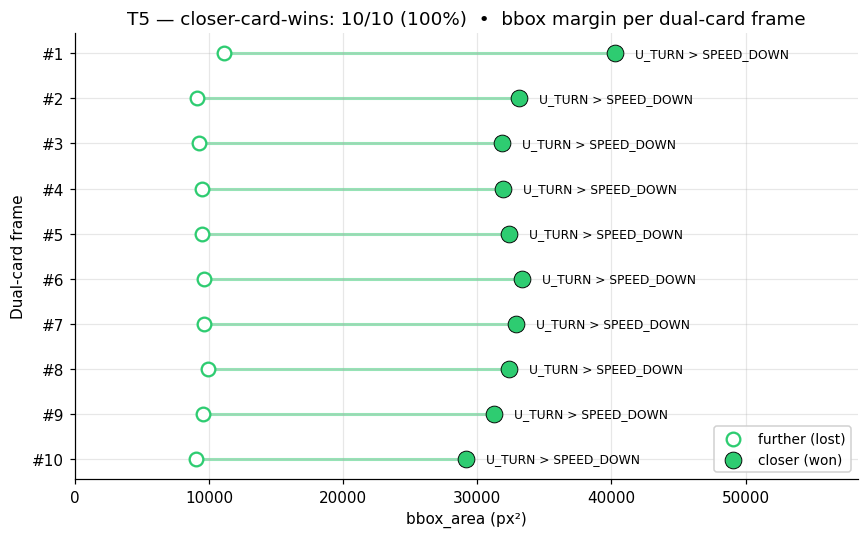

In [128]:
fig, ax = plt.subplots(figsize=(8, max(3.0, 0.35 * len(dual_t5) + 1.5)))

for _, row in dual_t5.iterrows():
    y = row['trial_idx']
    pass_color = '#2ecc71' if row['closer_wins'] else '#e74c3c'
    ax.plot(
        [row['further_bbox'], row['closer_bbox']], [y, y],
        color=pass_color, linewidth=2, alpha=0.5, zorder=1,
    )
    ax.scatter(
        row['further_bbox'], y,
        s=80, facecolors='white', edgecolors=pass_color, linewidth=1.5,
        zorder=2, label='further (lost)' if y == 1 else None,
    )
    ax.scatter(
        row['closer_bbox'], y,
        s=120, color=pass_color, edgecolors='black', linewidth=0.6,
        zorder=3, label='closer (won)' if y == 1 else None,
    )
    ax.annotate(
        f"{row['closer_content']} > {row['further_content']}",
        (max(row['closer_bbox'], row['further_bbox']) + 1500, y),
        fontsize=8, va='center',
    )

ax.set_yticks(list(dual_t5['trial_idx']))
ax.set_yticklabels([f"#{i}" for i in dual_t5['trial_idx']])
ax.invert_yaxis()
ax.set_xlabel('bbox_area (px²)')
ax.set_ylabel('Dual-card frame')
_pct = 100 * n_pass / n_total
ax.set_title(f"T5 — closer-card-wins: {n_pass}/{n_total} ({_pct:.0f}%)  •  bbox margin per dual-card frame")

# Pad x-axis to fit the annotation labels.
_xmax = float(dual_t5[['closer_bbox', 'further_bbox']].max().max())
ax.set_xlim(0, _xmax * 1.45)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
fig.savefig(FIGS / 't5_closer_wins.png', bbox_inches='tight')
plt.show()

## 7. T6 — Ablation (placeholder)

Drives Figure F6, V.2.4 ablation table, VI.1 strengths bullet, and the C4 + C2 originality narrative.

**TODO:**
1. Load both halves: `t6_ablation_baseline_*.csv` (filter on) and `t6_ablation_nofilter_*.csv` (filter off).
2. Per half: count true positives (intended STOP detected) and false positives (any command fired without a presented card).
3. Build the 2×2 table for V.2.4 directly from these numbers.
4. Render as a 2-bar chart with side-by-side TP / FP bars → save as `f6_ablation.png`.
5. Compute the headline number: false-positive-rate delta between configurations. This is the single most important sentence in V.2.4.

*(Fill in once T6 CSVs exist.)*

## Notes for fresh-machine runs

If running this notebook on a clean checkout:

```bash
pip install pandas matplotlib numpy jupyter
jupyter lab repo/results/analyze.ipynb
```

Or just open the file in Cursor / VS Code — the built-in notebook renderer works without a system Jupyter install. The `Setup` cell auto-detects the repo root and creates `repo/results/figures/` on first run.